VGG16 Feature map extraction

In [ ]:
from tensorflow.keras.applications import VGG16

In [ ]:
base_model = VGG16(weights='imagenet')

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:
from tensorflow.keras.models import Model

In [ ]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer('block5_pool').output)

In [ ]:
from tensorflow.keras.preprocessing import image

In [ ]:
img_dir='/content/drive/MyDrive/ROCo/test/radiology/images'

In [ ]:
import cv2
import numpy as np
import os

In [ ]:
image_files=[f for f in os.listdir(img_dir) if f.endswith(".jpg")]

In [ ]:
img_path=os.path.join(img_dir,image_files[0])

In [ ]:
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array=image.img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)
    img_array=preprocess_input(img_array)
    return img_array

In [ ]:
img=image.load_img(img_path,target_size=(224,224))

In [ ]:
img_array=image.img_to_array(img)
img_array

array([[[11., 11., 11.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.],
        ...,
        [ 2.,  2.,  2.],
        [ 3.,  3.,  3.],
        [11., 11., 11.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 3.,  3.,  3.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 1.,  1.,  1.],
        [ 2.,  2.,  2.],
        [ 7.,  7.,  7.]],

       ...,

       [[ 2.,  2.,  2.],
        [ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 5.,  5.,  5.],
        [ 4.,  4.,  4.],
        [ 3.,  3.,  3.],
        ...,
        [ 3.,  3.,  3.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.]]

In [ ]:
img_array=np.expand_dims(img_array,axis=0)
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 958ms/step


In [ ]:
n_features=feature_map.shape[-1]
n_features

512

In [ ]:
size=feature_map.shape[1]

In [ ]:
from PIL import Image

In [ ]:
img=Image.open(img_path)

In [ ]:
img.size

(693, 505)

In [ ]:
display_grid=np.zeros((size,size*n_features))
display_grid

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [ ]:
scale=20./n_features

In [ ]:
import matplotlib.pyplot as plt

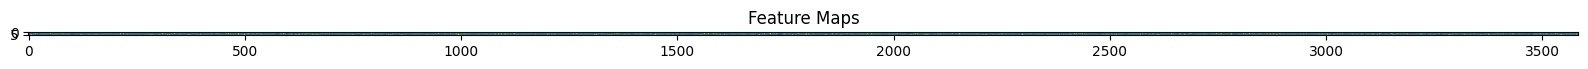

In [ ]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect='auto')

VGG19 feature map extraction

In [ ]:
from tensorflow.keras.applications import VGG19

In [ ]:
base_model = VGG19(weights='imagenet')

574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


In [ ]:
from tensorflow.keras.models import Model

In [ ]:
model=Model(inputs=base_model.input,outputs=base_model.get_layer('block5_pool').output)

In [ ]:
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size)
    img_array=image.img_to_array(img)
    img_array=np.expand_dims(img_array,axis=0)
    img_array=preprocess_input(img_array)
    return img_array

In [ ]:
img=image.load_img(img_path,target_size=(224,224))

In [ ]:
img_array=image.img_to_array(img)
img_array

array([[[11., 11., 11.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.],
        ...,
        [ 2.,  2.,  2.],
        [ 3.,  3.,  3.],
        [11., 11., 11.]],

       [[ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        [ 1.,  1.,  1.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.]],

       [[ 3.,  3.,  3.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 1.,  1.,  1.],
        [ 2.,  2.,  2.],
        [ 7.,  7.,  7.]],

       ...,

       [[ 2.,  2.,  2.],
        [ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 1.,  1.,  1.],
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.],
        [ 0.,  0.,  0.],
        [ 2.,  2.,  2.]],

       [[ 5.,  5.,  5.],
        [ 4.,  4.,  4.],
        [ 3.,  3.,  3.],
        ...,
        [ 3.,  3.,  3.],
        [ 3.,  3.,  3.],
        [ 5.,  5.,  5.]]

In [ ]:
img_array=np.expand_dims(img_array,axis=0)
feature_map=model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


In [ ]:
n_features=feature_map.shape[-1]
n_features

512

In [ ]:
for i in range(n_features):
  x=feature_map[0,:,:,i]
  x-=x.mean()
  x/=(x.std()+1e-5)
  x*=64
  x+=128
  x=np.clip(x,0,255).astype(int)
  display_grid[:,i*size:(i+1)*size]=x

In [ ]:
scale=20./n_features

In [ ]:
import matplotlib.pyplot as plt

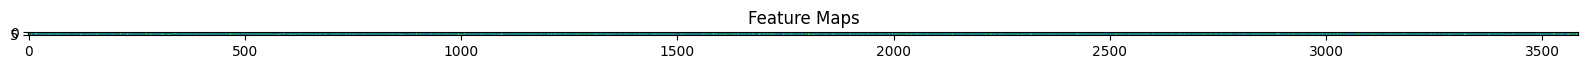

In [ ]:
plt.figure(figsize=(scale*n_features,scale))
plt.title("Feature Maps")
plt.grid(False)
plt.imshow(display_grid,aspect='auto')

ResNet

In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
base_model=tf.keras.applications.ResNet50(weights='imagenet',include_top=False)
base_model.trainable=False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
img=tf.keras.preprocessing.image.load_img(img_path,target_size=(224,224))

In [ ]:
img_array=tf.keras.preprocessing.image.img_to_array(img)
img_array=np.expand_dims(img_array,axis=0)

In [ ]:
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array=tf.keras.applications.resnet.preprocess_input(img_array)
img_array.shape

(1, 224, 224, 3)

In [ ]:
img_array

array([[[[ -92.939, -105.779, -112.68 ],
         [-100.939, -113.779, -120.68 ],
         [ -98.939, -111.779, -118.68 ],
         ...,
         [-101.939, -114.779, -121.68 ],
         [-100.939, -113.779, -120.68 ],
         [ -92.939, -105.779, -112.68 ]],

        [[-102.939, -115.779, -122.68 ],
         [-102.939, -115.779, -122.68 ],
         [-102.939, -115.779, -122.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ]],

        [[-100.939, -113.779, -120.68 ],
         [-103.939, -116.779, -123.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-102.939, -115.779, -122.68 ],
         [-101.939, -114.779, -121.68 ],
         [ -96.939, -109.779, -116.68 ]],

        ...,

        [[-101.939, -114.779, -121.68 ],
         [-102.939, -115.779, -122.68 ],
         [-103.939, -116.779, -123.68 ],
         ...,
         [-103.939, -116.779, -123.68 ],
         [-103.939, -1

In [ ]:
feature_map=base_model(img_array)

In [ ]:
feature_map

<tf.Tensor: shape=(1, 7, 7, 2048), dtype=float32, numpy=
array([[[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         ...,
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ]],

        [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.        ],
         [ 0.        ,  0.        ,  0.        , ...,  0.        ,
           0.14303786,  0.        ],
         [ 0.08277822,  0.        ,  0.        , ...,  0.        ,
           0.        ,  0.  

In [ ]:
feature_map.shape

TensorShape([1, 7, 7, 2048])

ANN

In [ ]:
import pandas as pd
data=pd.read_table(r"/content/drive/MyDrive/ROCo/test/radiology/captions.txt")
data

,ROCO_00001,Axial MRI (coronal view).
0,ROCO_00006,Coronal plain computed tomography image showi...
1,ROCO_00016,Axial source image from an intracranial magne...
2,ROCO_00025,"The apical height, homogeneity, and the thick..."
3,ROCO_00031,CTO of RCA (closure in the 2nd segment)
4,ROCO_00036,Venography shows a large amount of thrombogen...
...,...,...
8173,ROCO_81771,Damus–Kaye–Stansel shunt. Oblique coronal MIP...
8174,ROCO_81778,"MRI pelvis post-radiation, axial STIR/T2W FSE..."
8175,ROCO_81792,Fluoroscopic image showing attempts to grab t...
8176,ROCO_81796,Positron emission tomography–computed tomogra...


In [ ]:
data.columns=['label','caption']
data.head()

,label,caption
0,ROCO_00006,Coronal plain computed tomography image showi...
1,ROCO_00016,Axial source image from an intracranial magne...
2,ROCO_00025,"The apical height, homogeneity, and the thick..."
3,ROCO_00031,CTO of RCA (closure in the 2nd segment)
4,ROCO_00036,Venography shows a large amount of thrombogen...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf=TfidfVectorizer(max_features=50)
X=tfidf.fit_transform(data['caption']).toarray()
y=data['label']

In [ ]:
X

array([[0.45512116, 0.        , 0.        , ..., 0.        , 0.25202465,
        0.        ],
       [0.        , 0.        , 0.30263684, ..., 0.        , 0.19152729,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.23093458,
        0.        ],
       [0.        , 0.        , 0.23611011, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

In [ ]:
model=Sequential([
                Dense(64,activation="relu",input_shape=(X.shape[1],)),
                Dropout(0.5),
                Dense(32,activation="relu"),
                Dense(1,activation="sigmoid")

])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=Adam(learning_rate=0.001),loss=BinaryCrossentropy(),metrics=['accuracy'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
model.fit(X,y,epochs=10)

Epoch 1/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 5.9779e-05 - loss: -75797.3125
Epoch 2/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 2.4094e-04 - loss: -3204928.0000
Epoch 3/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 1.7612e-04 - loss: -18558416.0000
Epoch 4/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 1.3265e-04 - loss: -54235240.0000
Epoch 5/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0398e-04 - loss: -115269976.0000
Epoch 6/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.9336e-04 - loss: -211441456.0000
Epoch 7/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 1.8661e-04 - loss: -338878240.0000
Epoch 8/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 2.1092e-05 - loss: -508310272.0000
Epoch 9/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 4.2989e-04 - loss: -712075072.0000
Epoch 10/10
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 2.9822e-05 - loss: -959945088.0000


In [ ]:
loss,accuracy=model.evaluate(X,y)

256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 7.4517e-04 - loss: -592605568.0000


In [ ]:
loss,accuracy

(-1173874304.0, 0.00012227929255459458)

In [ ]:
model.predict(X)

256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

In [ ]:
y

array([   0,    1,    2, ..., 8175, 8176, 8177])

RNN

In [1]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 15.6 MB/s eta 0:00:00


In [2]:
from faker import Faker

In [3]:
import numpy as np

In [4]:
fake=Faker()
Faker.seed(42)

In [5]:
def generate_text_labels(num_samples=5000):
  text=[fake.sentence(nb_words=10) for i in range(num_samples)]
  labels=np.random.randint(0,2,num_samples)
  return text,labels

In [6]:
text,labels=generate_text_labels()

In [7]:
text

['Agent every development say quality throughout beautiful.',
 'All behavior discussion own night respond red information last everything thank.',
 'Recently future choice whatever from behavior benefit suggest.',
 'Enough analysis least by two bad fall pick those gun court attorney product.',
 'World talk term herself law street class great prove.',
 'Participant commercial rock clear here writer.',
 'Detail food shoulder argue start source husband at tree note responsibility defense material.',
 'Central cause seat much section investment on gun young catch management.',
 'Technology check civil quite others his.',
 'You more wife team activity result race Mr environment political born itself law.',
 'Will seven medical blood personal success medical current hear.',
 'Much single morning a food affect upon these.',
 'Dream drive note bad rule staff within mouth call.',
 'Water close month parent who up sense ready require human public health.',
 'Later easy ask again network open acc

In [8]:
labels

array([1, 1, 0, ..., 1, 0, 1])

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [10]:
tokenizer=Tokenizer(num_words=5000)

In [11]:
tokenizer.fit_on_texts(text)

In [12]:
sequences=tokenizer.texts_to_sequences(text)

In [13]:
sequences

[[738, 228, 739, 821, 378, 191, 650],
 [330, 29, 379, 487, 192, 782, 229, 740, 282, 42, 822],
 [230, 30, 331, 117, 741, 29, 231, 22],
 [651, 91, 283, 590, 284, 118, 285, 652, 119, 120, 783, 784, 332],
 [424, 193, 23, 425, 16, 43, 785, 426, 742],
 [333, 956, 286, 121, 334, 743],
 [957, 696, 92, 335, 653, 75, 122, 427, 428, 76, 591, 232, 194],
 [592, 233, 915, 697, 336, 593, 698, 120, 429, 123, 699],
 [744, 870, 700, 195, 337, 338],
 [5, 60, 44, 594, 339, 234, 488, 287, 288, 31, 654, 289, 16],
 [538, 430, 340, 61, 290, 235, 340, 952, 786],
 [697, 45, 964, 431, 696, 871, 936, 432],
 [380, 291, 76, 118, 823, 787, 152, 539, 341],
 [46, 655, 489, 32, 656, 196, 24, 197, 342, 788, 153, 236],
 [490, 491, 492, 62, 595, 824, 343, 745, 237, 2, 330, 596],
 [540, 292, 238, 433, 825, 124, 344, 541, 542, 77, 434, 381],
 [154, 78, 8, 701, 493, 382, 286, 345, 597, 783, 890],
 [33, 42, 63, 746, 383, 744, 93],
 [543, 155, 916, 29, 747, 702],
 [494, 657, 122, 198, 598, 424, 435, 541, 293, 294, 117],
 [332,

In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
padded_sequences=pad_sequences(sequences,maxlen=20)

In [15]:
padded_sequences[:2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        738, 228, 739, 821, 378, 191, 650],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 330,  29, 379, 487,
        192, 782, 229, 740, 282,  42, 822]], dtype=int32)

In [16]:
train_size=int(0.8*len(padded_sequences))
train_size

4000

In [17]:
X_train,X_test=padded_sequences[:train_size],padded_sequences[train_size:]
y_train,y_test=labels[:train_size],labels[train_size:]

In [18]:
X_train

array([[  0,   0,   0, ..., 378, 191, 650],
       [  0,   0,   0, ..., 282,  42, 822],
       [  0,   0,   0, ...,  29, 231,  22],
       ...,
       [  0,   0,   0, ..., 220, 935, 730],
       [  0,   0,   0, ..., 734, 649, 361],
       [  0,   0,   0, ...,   6,  63, 515]], dtype=int32)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

In [20]:
model=Sequential([Embedding(input_dim=5000,output_dim=64,input_length=20),
                  SimpleRNN(64,return_sequences=False),
                  Dense(1,activation="sigmoid")
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
model.compile(optimizer="adam",loss="binary_crossentropy",metrics=['accuracy'])

In [22]:
model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5088 - loss: 0.6957 - val_accuracy: 0.5175 - val_loss: 0.6943
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7964 - loss: 0.5644 - val_accuracy: 0.5075 - val_loss: 0.7890
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9196 - loss: 0.2561 - val_accuracy: 0.4850 - val_loss: 1.1787
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9850 - loss: 0.0792 - val_accuracy: 0.4737 - val_loss: 1.6589
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9957 - loss: 0.0295 - val_accuracy: 0.4800 - val_loss: 1.9754
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.4825 - val_loss: 2.2268
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.4863 - val_loss: 2.3805
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0

In [23]:
model.predict(X_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[8.87941539e-01],
       [7.82733143e-04],
       [1.60589173e-01],
       [7.04406321e-01],
       [2.84342244e-02],
       [8.42504874e-02],
       [8.44842754e-04],
       [3.03581764e-04],
       [9.91162419e-01],
       [8.09900403e-01],
       [9.98409986e-01],
       [6.91497917e-05],
       [9.99730885e-01],
       [9.96186137e-01],
       [3.93857583e-02],
       [9.96634901e-01],
       [9.94596660e-01],
       [2.24011391e-03],
       [3.01586509e-01],
       [2.80837361e-02],
       [9.99969482e-01],
       [9.19681847e-01],
       [9.99026597e-01],
       [6.00959233e-04],
       [6.77326918e-01],
       [2.14601710e-01],
       [5.36010775e-04],
       [9.99776363e-01],
       [9.84596610e-01],
       [2.10127383e-01],
       [9.12417889e-01],
       [9.95132864e-01],
       [1.58667695e-02],
       [7.97255218e-01],
       [4.04103473e-02],
       [9.99974728e-01],
       [9.90563035e-01],
       [7.37744034e-04],
       [1.03679586e-05],
       [9.97892380e-01],
